# Total score (recomputed angles + stored robustness)

Loads checkpoints written by [`compare_all_optimizers.ipynb`](compare_all_optimizers.ipynb) under `local/save/COMP/`.

- **Angle / length / assignment** scores are recomputed with current [`scoring_helpers.py`](scoring_helpers.py) (`get_period_angles` → `angle_score_function`, etc.), matching [`compare_all_other_scores.ipynb`](compare_all_other_scores.ipynb).
- **No SSIM / representation trajectory recomputation** — the representation-similarity term from `score_run` is **not** reconstructed.
- Instead, each period uses **`inverted_robustness_score = 1 - robustness`** from saved `period_robustness_rows`, with the **same weight (3.0)** that `repr_similarity_score` had in `compare_all_optimizers` (`SCORE_FACTORS`). See [`compare_all_robustness.ipynb`](compare_all_robustness.ipynb) for treating scalar robustness as `1 - robustness`.

**Total score per neuron–period:**  
`3·angle_score + 2·length_score + 0.1·n_partial_decay_score + 0.1·n_active_decay_score + 3·(1 - robustness)`


In [1]:
%load_ext autoreload
%autoreload 2

import gzip
import pickle
import sys
import warnings
from pathlib import Path
from typing import Any, Iterator, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm


def _find_project_root(start: Path | None = None) -> Path:
	p = (start or Path.cwd()).resolve()
	for cand in [p, *p.parents]:
		if (cand / "pyproject.toml").is_file():
			return cand
	return p


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(PROJECT_ROOT))

from visualize_webapp.app import (
	_NETWORK_SAMPLES_PER_DIGIT,
	_metrics,
	_nts,
	_opt_color,
	_opt_label,
	_sort_optimizer_ids,
)
from visualize_webapp.notebook.scoring_helpers import (
	angle_score_function,
	filter_periods,
	find_impacted_periods,
	get_assignments,
	get_iteration,
	get_n_assigned_digits,
	get_period_angles,
	get_recovery_periods,
	index_grp,
	length_score_function,
	n_active_decay,
	n_partial_decay,
	remove_inelligible_periods,
)
from visualize_webapp.post_processing import _pp_dead, _pp_neuron_digit

STRICT = False
BTSP_START_STRATEGY = "acceleration"
USE_REAL_PROGRESSION = True
SAVE_DIR = Path("local/save/COMP")

# Match compare_all_optimizers SCORE_FACTORS, but repr_similarity_score → inverted_robustness_score
SCORE_WEIGHTS: dict[str, float] = {
	"angle_score": 3.0,
	"length_score": 2.0,
	"n_partial_decay_score": 0.1,
	"n_active_decay_score": 0.1,
	"inverted_robustness_score": 3.0,
}


In [2]:
def rename_experiments(exp_name: str) -> str:
	if exp_name.startswith("digit_"):
		return " Control (no pretrain)"
	if "mislabel" in exp_name:
		return "Recover"
	if "relabel" in exp_name:
		return "Reinforce"
	return "Control"


def iter_saved_comp_results(save_dir: Path) -> Iterator[tuple[tuple[str, str], dict[str, Any]]]:
	"""Yield ``((experiment_id, optimizer_id), results_dict)`` for each COMP checkpoint on disk."""
	if not save_dir.is_dir():
		return
	for d in sorted(save_dir.iterdir(), key=lambda x: x.name):
		if not d.is_dir():
			continue
		key_csv = d / "key.csv"
		res_gz = d / "results.pkl.gz"
		res_pkl = d / "results.pkl"
		if not key_csv.is_file() or (not res_gz.is_file() and not res_pkl.is_file()):
			continue
		key_df = pd.read_csv(key_csv)
		if len(key_df) != 1:
			continue
		eid, oid = str(key_df["eid"].iloc[0]), str(key_df["oid"].iloc[0])
		if res_gz.is_file():
			with gzip.open(res_gz, "rb") as f:
				data = pickle.load(f)
		else:
			with open(res_pkl, "rb") as f:
				data = pickle.load(f)
		yield (eid, oid), data


def period_score_table(eid: str, mid: str, oid: str, rid: str) -> pd.DataFrame | None:
	"""Recompute angle / length / assignment columns (same as compare_all_other_scores / early score_run)."""

	metrics = _metrics(eid, mid, oid, rid=rid, w_cache=False)
	df_nd = cast(pd.DataFrame, _pp_neuron_digit(eid, mid, oid, rid=rid, w_cache=False))
	if df_nd is None or df_nd.empty:
		return None

	df_nd = df_nd.copy()
	df_nd["n_active"] = df_nd["status"].apply(
		lambda s: 0
		if s == "inactive"
		else (_NETWORK_SAMPLES_PER_DIGIT if s == "assigned" else int(s.split("_")[-1]))
	)
	df_nd["iteration"] = df_nd["checkpoint_idx"].map(lambda c: get_iteration(metrics, c))

	df_dead = cast(pd.DataFrame, _pp_dead(eid, mid, oid, rid=rid, w_cache=False))
	if df_dead is not None and not df_dead.empty:
		df_dead = df_dead.copy()
		df_dead["iteration"] = df_dead["checkpoint_idx"].map(lambda c: get_iteration(metrics, c))

	nts = _nts(eid, mid, oid, rid=rid, w_cache=False)

	n_assigned_digits = get_n_assigned_digits(df_nd)
	recovery_periods_any = get_recovery_periods(
		metrics, df_nd, n_assigned_digits, df_dead, mode="assigned_any"
	)
	recovery_periods_same = get_recovery_periods(
		metrics, df_nd, n_assigned_digits, df_dead, mode="assigned_same"
	)
	_ = find_impacted_periods(recovery_periods_any, recovery_periods_same)

	recovery_periods = recovery_periods_same
	recovery_periods = remove_inelligible_periods(recovery_periods)
	if df_dead is not None and not df_dead.empty:
		recovery_periods = filter_periods(recovery_periods, df_dead, strict=STRICT)

	if recovery_periods.empty:
		return None

	period_angles = get_period_angles(
		nts,
		recovery_periods,
		from_point=BTSP_START_STRATEGY,
		use_real_progression=USE_REAL_PROGRESSION,
	)
	angles_scores = period_angles.assign(
		angle_score=lambda df: df["activation_angle"].map(angle_score_function)
	).drop(columns=["activation_angle"])

	length_scores = (
		recovery_periods[index_grp + ["total_length_iter"]]
		.assign(length_score=lambda df: df["total_length_iter"].map(length_score_function))
		.drop(columns=["total_length_iter"])
		.set_index(index_grp)
	)

	assignments = get_assignments(df_nd, recovery_periods)
	assignment_scores = assignments.groupby(index_grp, sort=False).apply(
		lambda df: pd.Series(
			{
				"n_partial_decay_score": n_partial_decay(int(df["n_partial_at_start"].iloc[0])),
				"n_active_decay_score": n_active_decay(int(df["n_assigned_at_start"].iloc[0])),
			}
		)
	)

	return angles_scores.join(length_scores).join(assignment_scores)


In [3]:
loaded = dict(iter_saved_comp_results(SAVE_DIR))
if not loaded:
	warnings.warn(f"No COMP results under {SAVE_DIR.resolve()}", UserWarning)

plot_rows: list[dict] = []
skipped: list[tuple[str, str, str]] = []

for (eid, oid), out in tqdm(loaded.items(), desc="runs"):
	if out.get("error"):
		skipped.append((eid, oid, str(out.get("error"))))
		continue
	mid, rid = out.get("mid"), out.get("rid")
	if mid is None or rid is None:
		skipped.append((eid, oid, "missing mid/rid in pickle"))
		continue

	base = period_score_table(eid, mid, oid, rid)
	if base is None or base.empty:
		skipped.append((eid, oid, "no recovery periods / empty neuron_digit"))
		continue

	rob_list = out.get("period_robustness_rows") or []
	if not rob_list:
		skipped.append((eid, oid, "no period_robustness_rows"))
		continue

	df_rob = pd.DataFrame(rob_list)
	if df_rob.empty:
		continue
	df_rob = df_rob.drop_duplicates(subset=["neuron_id", "period_id"], keep="first")
	df_rob = df_rob.set_index(["neuron_id", "period_id"])[["robustness"]].copy()
	df_rob["inverted_robustness_score"] = 1.0 - pd.to_numeric(df_rob["robustness"], errors="coerce")
	df_rob = df_rob.drop(columns=["robustness"])

	merged = base.join(df_rob, how="left")
	if merged["inverted_robustness_score"].notna().sum() == 0:
		skipped.append((eid, oid, "no robustness matched any period"))
		continue

	merged["total_score"] = sum(
		merged[c].astype(float) * w for c, w in SCORE_WEIGHTS.items()
	)
	exp_label = rename_experiments(eid)
	for ts in merged["total_score"].astype(float):
		if not np.isfinite(ts):
			continue
		plot_rows.append(
			{"experiment": exp_label, "experiment_id": eid, "optimizer_id": oid, "total_score": float(ts)}
		)

df_plot = pd.DataFrame.from_records(plot_rows)
print(f"points: {len(df_plot)}, runs loaded: {len(loaded)}, skipped: {len(skipped)}")
if skipped:
	print("first skips:", skipped[:8])
df_plot.head()


runs:   0%|          | 0/20 [00:00<?, ?it/s]

Removing 28 period(s) that do not last until the end of their trial.
Removing: neuron_id            dnn|hidden.2|neuron|46
layer_name                         hidden.2
period_id                                 0
start                                   321
end                                   326.0
start_iter                              317
end_iter                                322
total_length_iter                         5
Name: 9, dtype: object

Removing: neuron_id            dnn|hidden.4|neuron|1
layer_name                        hidden.4
period_id                                0
start                                  207
end                                  245.0
start_iter                             204
end_iter                               242
total_length_iter                       38
Name: 15, dtype: object

Removing: neuron_id            dnn|hidden.4|neuron|17
layer_name                         hidden.4
period_id                                 0
start                   

,experiment,experiment_id,optimizer_id,total_score
0,Control (no pretrain),digit_ordered_0_1_75_25_tr100,adagrad_lr0.01,6.431413
1,Control (no pretrain),digit_ordered_0_1_75_25_tr100,adagrad_lr0.01,7.150423
2,Control (no pretrain),digit_ordered_0_1_75_25_tr100,adagrad_lr0.01,7.899246
3,Control (no pretrain),digit_ordered_0_1_75_25_tr100,adagrad_lr0.01,7.841649
4,Control (no pretrain),digit_ordered_0_1_75_25_tr100,adagrad_lr0.01,3.383069


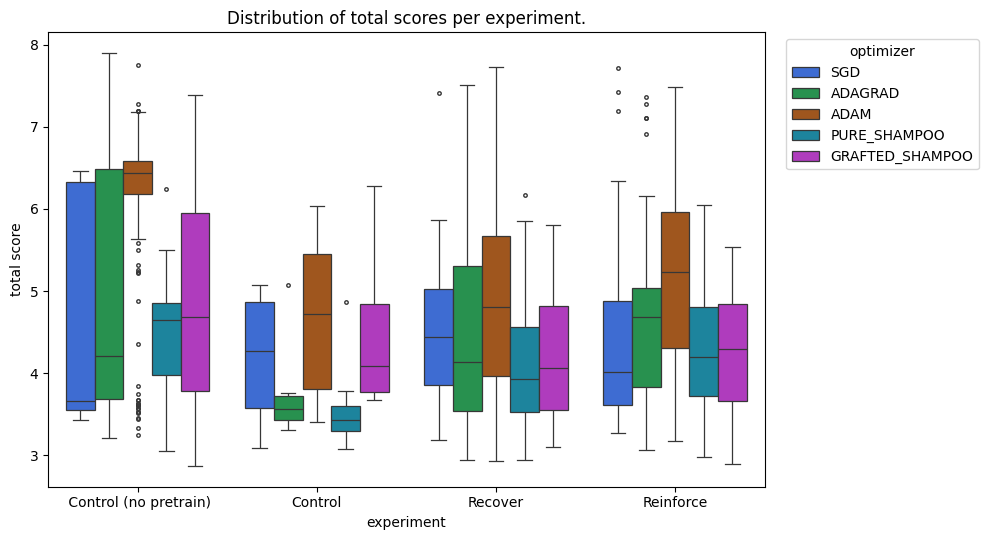

In [6]:
if df_plot.empty:
	print("Nothing to plot.")
else:
	exp_order = sorted(df_plot["experiment"].unique())
	opt_order = _sort_optimizer_ids(df_plot["optimizer_id"].unique().tolist())
	palette = [_opt_color(o) for o in opt_order]
	fig, ax = plt.subplots(figsize=(max(10, len(exp_order) * 1.4), 5.5))
	sns.boxplot(
		data=df_plot,
		x="experiment",
		y="total_score",
		hue="optimizer_id",
		order=exp_order,
		hue_order=opt_order,
		palette=palette,
		dodge=True,
		ax=ax,
		linewidth=0.9,
		fliersize=2.5,
	)
	ax.set_xlabel("experiment")
	ax.set_ylabel("total score")
	ax.set_title(
		"Distribution of total scores per experiment."
	)
	ax.tick_params(axis="x")
	handles, labels = ax.get_legend_handles_labels()
	ax.legend(
		handles,
		[_opt_label(lbl) for lbl in labels],
		title="optimizer",
		bbox_to_anchor=(1.02, 1),
		loc="upper left",
	)
	plt.tight_layout()
	plt.show()
